# Iteration 8 — Few-Shot Seq2Seq Classification with Flan-T5 (RQ2)

## Research Questions Addressed

| RQ | Question | Target |
|----|----------|--------|
| **RQ2** | How do traditional ML models compare with transformer-based and LLM-based approaches? | Macro-F1 ≥ 0.7825 |

## Experimental Design

| Component | Detail |
|-----------|--------|
| **Model** | `google/flan-t5-large` (780 M parameters); optionally `flan-t5-xl` (3 B) |
| **Method** | Few-shot candidate-label scoring via sequence-to-sequence log-likelihood |
| **Languages** | English, German, Swedish, Dutch |
| **Datasets** | 4 per-language JSON files from `Master Dataset 34k/By_SL_Country/` |
| **Split strategy** | `StratifiedGroupKFold` on unique `text_id` → train / validation / test; leakage-safe |
| **Few-shot source** | Exemplars drawn **only** from the training split (2 per class per language) |
| **Baseline** | Iteration 0: BERT + SVM, Macro-F1 = 0.7825 (English) |
| **Hardware** | MacBook Air M4 / Apple Silicon — MPS-safe workflow, `torch.float32` |

## Notebook Structure

| Part | Purpose |
|------|---------|
| **Part A — Exploratory** | Task understanding, prompt design, few-shot exemplar construction, validation-only debugging |
| **Part B — Frozen Benchmark** | Final held-out test evaluation, fair model comparison, RQ2 reporting |

## Outputs

- Per-language and overall classification metrics (accuracy, macro-F1, PS / NPS precision, recall, F1)
- Per-language and overall confusion matrices, ROC curves, PR curves, metrics bar charts — all as separate academic-quality figures (8 × 6, 300 dpi, PNG + PDF)
- `iteration_8_merged_summary.json` — structured summary with gap analysis against RQ2 target

## 1. Imports, Warnings, and Randomness

Loads all required libraries (NumPy, pandas, PyTorch, Hugging Face Transformers, scikit-learn, matplotlib, seaborn), suppresses warnings, and sets the global random seed (`SEED = 42`) for reproducibility. MPS fallback is enabled for Apple Silicon compatibility.

In [1]:
# =============================================================================
# IMPORTS, WARNINGS, RANDOMNESS — ITERATION 8
# =============================================================================
import os
import re
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Runtime Configuration

Sets the hardware device (MPS / CPU), token budget, checkpoint interval, the RQ2 macro-F1 target (0.7825), and the list of Flan-T5 model variants to benchmark. `RUN_XL = False` is the safe default for Apple Silicon; enable only if the machine can reliably load `flan-t5-xl` (≈ 12 GB).

In [2]:
# =============================================================================
# DEVICE + MODEL CONFIGURATION
# =============================================================================
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", DEVICE)

DEBUG_MODE = True
RUN_XL = False

if DEBUG_MODE:
    MAX_SOURCE_TOKENS = 320
else:
    MAX_SOURCE_TOKENS = 384

MAX_LABEL_TOKENS = 16
CHECKPOINT_EVERY = 50
RQ2_TARGET_MACRO_F1 = 0.7825

MODELS_TO_COMPARE = ["google/flan-t5-large"]
if RUN_XL:
    MODELS_TO_COMPARE.append("google/flan-t5-xl")

CLASS_LABELS = ["Process Safety", "Non-Process Safety"]

print("Models:", MODELS_TO_COMPARE)
print("MAX_SOURCE_TOKENS:", MAX_SOURCE_TOKENS)
print("RQ2 target macro-F1:", RQ2_TARGET_MACRO_F1)


Using device: mps
Models: ['google/flan-t5-large']
MAX_SOURCE_TOKENS: 320
RQ2 target macro-F1: 0.7825


## 3. Project Root Detection and Paths

Discovers the project root by searching upward for the `Datasets/` or `Master Dataset 34k/` directory. Creates the iteration-specific results tree (`Results/_iteration_8/`) with sub-folders for artefacts, metrics, and figures.

In [3]:
# =============================================================================
# PROJECT ROOT + PATHS
# =============================================================================
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / "Datasets").exists() or (cur / "Master Dataset 34k").exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        "Could not find project root with 'Datasets' or 'Master Dataset 34k'. "
        "Set THESIS_BASE_DIR if needed."
    )

env_base = os.environ.get("THESIS_BASE_DIR")
if env_base:
    BASE_DIR = Path(env_base).resolve()
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())

PATHS = {
    "base": BASE_DIR,
    "master_dataset": BASE_DIR / "Master Dataset 34k",
    "results": BASE_DIR / "Results" / "_iteration_8",
    "artifacts": BASE_DIR / "Results" / "_iteration_8" / "artifacts",
    "metrics": BASE_DIR / "Results" / "_iteration_8" / "metrics",
    "figures": BASE_DIR / "Results" / "_iteration_8" / "figures",
}

for key, path in PATHS.items():
    if key not in {"base", "master_dataset"}:
        path.mkdir(parents=True, exist_ok=True)

DATASET_FILES = {
    "english_manual":  PATHS["master_dataset"] / "By_SL_Country" / "master_df_English_manual.json",
    "german_manual":   PATHS["master_dataset"] / "By_SL_Country" / "master_df_Germany_manual.json",
    "swedish_manual":  PATHS["master_dataset"] / "By_SL_Country" / "master_df_Sweden_manual.json",
    "dutch_manual":    PATHS["master_dataset"] / "By_SL_Country" / "master_df_Netherlands_manual.json",
}

DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if v.exists()}

DATASET_KEY_TO_LANGUAGE = {
    "english_manual": "English",
    "german_manual": "German",
    "swedish_manual": "Swedish",
    "dutch_manual": "Dutch",
}

print("BASE_DIR:", BASE_DIR)
print("Available datasets:", list(DATASET_FILES.keys()))


BASE_DIR: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Available datasets: ['english_manual', 'german_manual', 'swedish_manual', 'dutch_manual']


## 4. Load and Combine Multilingual Data

Loads the four per-language JSON datasets (English, German, Swedish, Dutch), validates required columns (`TITLE`, `CASE_DESCRIPTION`, `CASE_TYPE`), tags each record with its language and dataset key, and concatenates into a single combined DataFrame.

In [4]:
# =============================================================================
# LOAD AND COMBINE DATA
# =============================================================================
all_dfs = []

for dataset_key, json_path in DATASET_FILES.items():
    language = DATASET_KEY_TO_LANGUAGE.get(dataset_key, "Unknown")
    df_part = pd.read_json(json_path)

    required_cols = ["TITLE", "CASE_DESCRIPTION", "CASE_TYPE"]
    missing = [c for c in required_cols if c not in df_part.columns]
    if missing:
        raise ValueError(f"{json_path.name} is missing required columns: {missing}")

    keep_cols = [c for c in ["TITLE", "CASE_DESCRIPTION", "CASE_TYPE", "CASENO", "SL_COUNTRY"] if c in df_part.columns]
    df_part = df_part[keep_cols].copy()
    df_part["LANGUAGE"] = language
    df_part["DATASET_KEY"] = dataset_key

    all_dfs.append(df_part)

if not all_dfs:
    raise FileNotFoundError("No dataset JSON files were found.")

df = pd.concat(all_dfs, ignore_index=True)

print("Combined shape:", df.shape)
df.head()


Combined shape: (33878, 7)


,TITLE,CASE_DESCRIPTION,CASE_TYPE,CASENO,SL_COUNTRY,LANGUAGE,DATASET_KEY
0,Insufficient PPE being worn in laboratory.,Person not wearing safety glasses nor safety g...,Safety,55731,UK,English,english_manual
1,Struck building with digger,Works ongoing to dig out drainage channels nex...,Asset and Reputation damage/loss,54924,UK,English,english_manual
2,Contractor smelling of alcohol,During CDM induction contractor presented smel...,Safety,55896,UK,English,english_manual
3,New Aerial photographs have revealed that a la...,"While reviewing pipeline ""fly-by"" images it ha...",Asset and Reputation damage/loss,43529,UK,English,english_manual
4,CW Discharge Pipework Failure,CW Discharge Pipework failure. Main CW pimp In...,Process Safety,49329,UK,English,english_manual


## 5. Clean Text and Create the Binary Target

Normalises whitespace, builds a combined `TEXT` field (`Title: ... \n Description: ...`), filters records shorter than 20 characters, and creates the binary label (`Process Safety` vs. `Non-Process Safety`). Assigns a stable `text_id` for grouped splitting.

In [5]:
# =============================================================================
# CLEANING + TARGET
# =============================================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

for col in ["TITLE", "CASE_DESCRIPTION", "CASE_TYPE", "LANGUAGE"]:
    df[col] = df[col].apply(clean_text)

df["TEXT"] = (
    "Title: " + df["TITLE"].fillna("") +
    "\nDescription: " + df["CASE_DESCRIPTION"].fillna("")
).str.strip()

df = df[df["TEXT"].str.len() > 20].copy()

df["binary_label"] = np.where(
    df["CASE_TYPE"] == "Process Safety",
    "Process Safety",
    "Non-Process Safety"
)

df["text_id"] = pd.factorize(df["TEXT"])[0]

print(df["binary_label"].value_counts())
print("Rows after cleaning:", len(df))


binary_label
Non-Process Safety    29447
Process Safety         4431
Name: count, dtype: int64
Rows after cleaning: 33878


## 6. Build a Leakage-Safe Grouped Split

Uses `StratifiedGroupKFold` on unique `text_id` values to create train / validation / test partitions that prevent data leakage from duplicate texts. The split is saved to `artifacts/split_assignments.csv` so that it can be reused across runs and verified.

In [6]:
# =============================================================================
# SPLIT BY UNIQUE TEXTS
# =============================================================================
unique_for_split = (
    df[["text_id", "TEXT", "binary_label", "LANGUAGE"]]
    .drop_duplicates("text_id")
    .reset_index(drop=True)
)

min_class_count = unique_for_split["binary_label"].value_counts().min()
if min_class_count < 2:
    raise ValueError("Not enough examples per class to create a grouped split.")

n_splits = min(5, int(min_class_count))
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
splits = list(
    sgkf.split(
        X=unique_for_split["TEXT"],
        y=unique_for_split["binary_label"],
        groups=unique_for_split["text_id"]
    )
)

train_idx, test_idx = splits[0]
train_val = unique_for_split.iloc[train_idx].copy()
test_unique = unique_for_split.iloc[test_idx].copy()

min_class_count_inner = train_val["binary_label"].value_counts().min()
n_splits_inner = min(5, int(min_class_count_inner)) if min_class_count_inner >= 2 else 2

sgkf_inner = StratifiedGroupKFold(n_splits=n_splits_inner, shuffle=True, random_state=SEED)
inner_splits = list(
    sgkf_inner.split(
        X=train_val["TEXT"],
        y=train_val["binary_label"],
        groups=train_val["text_id"]
    )
)

inner_train_idx, inner_val_idx = inner_splits[0]
train_unique = train_val.iloc[inner_train_idx].copy()
val_unique = train_val.iloc[inner_val_idx].copy()

split_assignments = pd.concat([
    train_unique.assign(split="train"),
    val_unique.assign(split="val"),
    test_unique.assign(split="test")
], ignore_index=True)

split_assignments.to_csv(PATHS["artifacts"] / "split_assignments.csv", index=False)
split_assignments["split"].value_counts()


split
train    20939
test      6543
val       5235
Name: count, dtype: int64

# Part A — Exploratory Phase (Train / Validation Only)

The cells below are used for task understanding, prompt design, few-shot exemplar construction, validation-only debugging, and error analysis. **The test set is not accessed in this section.** All exploratory outputs are saved to `artifacts/` for reproducibility.

## 7. Exploratory Data Overview

Prints the per-split, per-language, per-class record counts for the train and validation partitions. Saved to `artifacts/train_val_label_overview.csv`.

In [7]:
# =============================================================================
# EXPLORATORY DATA OVERVIEW
# =============================================================================
train_val_rows = df.merge(split_assignments[["text_id", "split"]], on="text_id", how="left")
train_val_rows = train_val_rows[train_val_rows["split"].isin(["train", "val"])].copy()

overview = (
    train_val_rows.groupby(["split", "LANGUAGE", "binary_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "LANGUAGE", "binary_label"])
)

overview.to_csv(PATHS["artifacts"] / "train_val_label_overview.csv", index=False)
overview.head(20)


,split,LANGUAGE,binary_label,count
0,train,Dutch,Non-Process Safety,909
1,train,Dutch,Process Safety,367
2,train,English,Non-Process Safety,2123
3,train,English,Process Safety,892
4,train,German,Non-Process Safety,8537
5,train,German,Process Safety,1070
6,train,Swedish,Non-Process Safety,7361
7,train,Swedish,Process Safety,489
8,val,Dutch,Non-Process Safety,226
9,val,Dutch,Process Safety,92


## 8. Build Train-Only Few-Shot Exemplars

Selects 2 exemplars per class per language from the **training split only** (never from validation or test). The exemplars are saved to `artifacts/few_shot_exemplars.json` and used in the prompt template for both exploratory and benchmark runs.

In [8]:
# =============================================================================
# FEW-SHOT EXEMPLARS FROM TRAIN ONLY
# =============================================================================
train_rows = df.merge(split_assignments[["text_id", "split"]], on="text_id", how="left")
train_rows = train_rows[train_rows["split"] == "train"].copy()

EXEMPLARS = {}

for language in sorted(train_rows["LANGUAGE"].unique()):
    EXEMPLARS[language] = {}
    for label in CLASS_LABELS:
        subset = train_rows[
            (train_rows["LANGUAGE"] == language) &
            (train_rows["binary_label"] == label)
        ].drop_duplicates("text_id")

        sample_n = min(2, len(subset))
        sampled = subset.sample(sample_n, random_state=SEED) if sample_n > 0 else subset

        EXEMPLARS[language][label] = [
            {
                "title": row["TITLE"],
                "description": row["CASE_DESCRIPTION"]
            }
            for _, row in sampled.iterrows()
        ]

EXEMPLARS["DEFAULT"] = EXEMPLARS.get("English", EXEMPLARS[next(iter(EXEMPLARS))])

with open(PATHS["artifacts"] / "few_shot_exemplars.json", "w", encoding="utf-8") as f:
    json.dump(EXEMPLARS, f, indent=2)

EXEMPLARS


{'Dutch': {'Process Safety': [{'title': 'Oude gasfles afvoeren (propaan)',
    'description': 'In de gasflessenopslag RoCa staat al maanden een grote (100L) en zeer oude gasfles; productiedatum 1986/ uiterste herkeur 1996! De fles is in zeer slechte staat en bevat nog een onbekende hoeveelheid propaan.'},
   {'title': 'Onopvallende Brandvertragende Plaat leidt tot val van medewerker ELD',
    'description': 'Een medewerker was bezig om een afvoerslang richting de afvoer te plaatsen. Tijdens deze werkzaamheden ging hij staan op een oude spuitput, die was afgedekt met een brandvertragende plaat. Helaas brak deze plaat, waardoor de medewerker met één been in de put viel tot aan zijn middel. De medewerker heeft hierbij twee schaafwonden opgelopen: één op zijn linkerdijbeen en één op zijn rechterelleboog, en hij ervaart enige pijn in zijn rechterknie. Het was niet duidelijk dat de plaat een brandvertragende functie had en niet bedoeld was om op te staan. Visueel leek het op een gewoon vloer

## 9. Prompt Definition and Candidate-Label Scoring

Defines the process-safety definition, the few-shot prompt builder, and the candidate-label scoring function. Rather than unconstrained text generation, the model scores each candidate label (`Process Safety`, `Non-Process Safety`) by its sequence log-likelihood and normalises into probabilities — this avoids label hallucination and parsing fragility.

In [9]:
# =============================================================================
# PROMPT DEFINITION + SCORING
# =============================================================================
PROCESS_SAFETY_DEFINITION = '''
A Process Safety incident involves failures, leaks, releases, trips, shutdowns, pressure deviations,
fires, explosions, ruptures, or other hazardous events arising from process equipment, process systems,
or industrial plant operations.

A Non-Process Safety incident includes personal safety incidents, slips, trips, falls, minor administrative
issues, office/workshop events, traffic/vehicle incidents, or other events not arising from process systems.
'''.strip()

def get_language_exemplars(language: str):
    if language in EXEMPLARS:
        return EXEMPLARS[language]
    return EXEMPLARS["DEFAULT"]

def build_few_shot_prompt(title: str, description: str, language: str) -> str:
    ex = get_language_exemplars(language)

    blocks = []
    for label in CLASS_LABELS:
        for item in ex.get(label, []):
            blocks.append(
                f"Example\n"
                f"Title: {item['title']}\n"
                f"Description: {item['description']}\n"
                f"Classification: {label}"
            )

    examples_text = "\n\n".join(blocks)

    prompt = (
        "You are an expert industrial safety analyst.\n"
        "Classify the incident into exactly one of the following labels:\n"
        "- Process Safety\n"
        "- Non-Process Safety\n\n"
        f"{PROCESS_SAFETY_DEFINITION}\n\n"
        f"{examples_text}\n\n"
        f"Now classify this incident.\n"
        f"Title: {title}\n"
        f"Description: {description}\n\n"
        "Answer:"
    )
    return prompt

def build_label_token_cache(tokenizer):
    cache = {}
    for label in CLASS_LABELS:
        cache[label] = tokenizer(
            label,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LABEL_TOKENS
        ).input_ids
    return cache

@torch.no_grad()
def score_candidate_labels(prompt: str, tokenizer, model, label_token_cache):
    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SOURCE_TOKENS
    )

    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    scores = []
    for label in CLASS_LABELS:
        label_ids = label_token_cache[label].to(DEVICE)

        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=label_ids
        )

        seq_len = label_ids.shape[1]
        sequence_log_score = -float(out.loss.detach().cpu()) * seq_len
        scores.append(sequence_log_score)

    scores = np.array(scores, dtype=np.float64)
    probs = np.exp(scores - scores.max())
    probs = probs / probs.sum()

    scored = pd.DataFrame({
        "label": CLASS_LABELS,
        "score": scores,
        "prob": probs
    }).sort_values("score", ascending=False).reset_index(drop=True)

    return scored

def classify_incident(title, description, language, tokenizer, model, label_token_cache):
    prompt = build_few_shot_prompt(title=title, description=description, language=language)
    scored = score_candidate_labels(prompt, tokenizer, model, label_token_cache)

    top1 = scored.iloc[0]
    top2 = scored.iloc[1]

    return {
        "pred_label": top1["label"],
        "pred_confidence": float(top1["prob"]),
        "score_margin": float(top1["score"] - top2["score"]),
        "top2_labels": scored["label"].tolist(),
        "top2_probs": scored["prob"].tolist(),
        "prompt": prompt
    }


## 10. Prompt Inspection

Prints a single fully-assembled few-shot prompt for manual inspection before running model inference. Verifies that the exemplars, definitions, and formatting are correct.

In [10]:
# =============================================================================
# PROMPT INSPECTION
# =============================================================================
sample_train = train_rows.drop_duplicates("text_id").iloc[0]
sample_prompt = build_few_shot_prompt(
    title=sample_train["TITLE"],
    description=sample_train["CASE_DESCRIPTION"],
    language=sample_train["LANGUAGE"]
)

print(sample_prompt[:4000])


You are an expert industrial safety analyst.
Classify the incident into exactly one of the following labels:
- Process Safety
- Non-Process Safety

A Process Safety incident involves failures, leaks, releases, trips, shutdowns, pressure deviations,
fires, explosions, ruptures, or other hazardous events arising from process equipment, process systems,
or industrial plant operations.

A Non-Process Safety incident includes personal safety incidents, slips, trips, falls, minor administrative
issues, office/workshop events, traffic/vehicle incidents, or other events not arising from process systems.

Example
Title: Operational Loss - Dust silo routes not available - risk to generation
Description: Both mixers and TD pumps were unavailable on 14/15th Feb and silo levels peaked, coming close to affecting precip dusting and therefore unit availability. Mixer 6 had an inverter fault on 14th (on-going investigation/repairs), TD pump had processor failure on 14th and mixer 4 was out for maintena

## 11. Smoke Test on a Single Validation Example

Loads the first Flan-T5 model, runs candidate-label scoring on one validation record, and displays the predicted label and confidence. Confirms that the pipeline produces valid output before committing to a full run.

In [11]:
# =============================================================================
# SINGLE-EXAMPLE SMOKE TEST
# =============================================================================
sample_val = df.merge(split_assignments[["text_id", "split"]], on="text_id", how="left")
sample_val = sample_val[sample_val["split"] == "val"].drop_duplicates("text_id").iloc[0]

tokenizer = AutoTokenizer.from_pretrained(MODELS_TO_COMPARE[0])
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODELS_TO_COMPARE[0],
    torch_dtype=torch.float32
).to(DEVICE)
model.eval()

label_token_cache = build_label_token_cache(tokenizer)

smoke = classify_incident(
    title=sample_val["TITLE"],
    description=sample_val["CASE_DESCRIPTION"],
    language=sample_val["LANGUAGE"],
    tokenizer=tokenizer,
    model=model,
    label_token_cache=label_token_cache
)
smoke


`torch_dtype` is deprecated! Use `dtype` instead!


{'pred_label': 'Non-Process Safety',
 'pred_confidence': 0.8816816138908676,
 'score_margin': 2.0084518305957317,
 'top2_labels': ['Non-Process Safety', 'Process Safety'],
 'top2_probs': [0.8816816138908676, 0.11831838610913235],
 'prompt': 'You are an expert industrial safety analyst.\nClassify the incident into exactly one of the following labels:\n- Process Safety\n- Non-Process Safety\n\nA Process Safety incident involves failures, leaks, releases, trips, shutdowns, pressure deviations,\nfires, explosions, ruptures, or other hazardous events arising from process equipment, process systems,\nor industrial plant operations.\n\nA Non-Process Safety incident includes personal safety incidents, slips, trips, falls, minor administrative\nissues, office/workshop events, traffic/vehicle incidents, or other events not arising from process systems.\n\nExample\nTitle: Operational Loss - Dust silo routes not available - risk to generation\nDescription: Both mixers and TD pumps were unavailable

## 12. Validation Debugging Run

Classifies a small per-language subset of the validation split to check whether the prompt and exemplars produce sensible predictions. This is **not** the final benchmark — it is a development-only step. Predictions are saved to `artifacts/validation_debug_predictions.csv`.

In [12]:
# =============================================================================
# VALIDATION DEBUGGING RUN
# =============================================================================
def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

val_rows = df.merge(split_assignments[["text_id", "split"]], on="text_id", how="left")
val_rows = val_rows[val_rows["split"] == "val"].drop_duplicates("text_id").reset_index(drop=True)

# small subset for debugging
debug_val = val_rows.groupby("LANGUAGE", group_keys=False).head(5).reset_index(drop=True)

debug_predictions = []

for _, row in tqdm(debug_val.iterrows(), total=len(debug_val), desc="validation_debug"):
    result = classify_incident(
        title=row["TITLE"],
        description=row["CASE_DESCRIPTION"],
        language=row["LANGUAGE"],
        tokenizer=tokenizer,
        model=model,
        label_token_cache=label_token_cache
    )

    debug_predictions.append({
        "text_id": row["text_id"],
        "LANGUAGE": row["LANGUAGE"],
        "TITLE": row["TITLE"],
        "CASE_DESCRIPTION": row["CASE_DESCRIPTION"],
        "gold_label": row["binary_label"],
        "pred_label": result["pred_label"],
        "pred_confidence": result["pred_confidence"],
        "score_margin": result["score_margin"],
    })

    clear_memory()

debug_val_df = pd.DataFrame(debug_predictions)
debug_val_df.to_csv(PATHS["artifacts"] / "validation_debug_predictions.csv", index=False)
debug_val_df


validation_debug:   0%|          | 0/20 [00:00<?, ?it/s]

,text_id,LANGUAGE,TITLE,CASE_DESCRIPTION,gold_label,pred_label,pred_confidence,score_margin
0,2,English,Contractor smelling of alcohol,During CDM induction contractor presented smel...,Non-Process Safety,Non-Process Safety,0.881682,2.008452
1,8,English,Unit 1 Cooling Tower Fan A1 Drive shaft rotation.,Work in progress was the exchange of the cooli...,Process Safety,Non-Process Safety,0.881682,2.008452
2,15,English,Canteen Cooking Oil container left on pathway,Canteen Cooking Oil container left on pathway,Non-Process Safety,Non-Process Safety,0.881682,2.008452
3,23,English,Oil leaking from Unit 1 HP Upper Governor oil ...,"Unit was on load, oil mist and abnormal odour ...",Process Safety,Non-Process Safety,0.881682,2.008452
4,25,English,Poor management of unloading activities.,Several observations made regarding FLT condit...,Non-Process Safety,Non-Process Safety,0.881682,2.008452
5,4707,German,Wa1 EB-Trafostation Oberbecken Absturzgefahr,Im Bereich der EB-Trafostation am Oberbecken b...,Non-Process Safety,Non-Process Safety,0.973880,3.618591
6,4713,German,"Arbeitsplatz, ROG 1400, 1. OG","Aktuell noch kein vernünftiger Schreibtisch, b...",Non-Process Safety,Non-Process Safety,0.973880,3.618591
7,4721,German,Prüffrist Leiter abgelaufen,Leiter-Nr. 183 im Lagerraum (Antriebe) im 20kV...,Non-Process Safety,Non-Process Safety,0.973880,3.618591
8,4726,German,Fuß Verletzung beim Verlassen des Dienstfahrze...,Am 31. August 2021: Ein Mitarbeiter hat nach s...,Non-Process Safety,Non-Process Safety,0.973880,3.618591
9,4732,German,Stolperunfall im Homeoffice,Der IP stolperte im Umfeld seines Schreibtisch...,Non-Process Safety,Non-Process Safety,0.973880,3.618591


## 13. Validation Error Analysis

Inspects misclassified validation records to identify systematic failure modes before freezing the benchmark setup. Errors are saved to `artifacts/validation_debug_errors.csv`.

In [13]:
# =============================================================================
# VALIDATION ERROR ANALYSIS
# =============================================================================
val_errors = debug_val_df[debug_val_df["gold_label"] != debug_val_df["pred_label"]].copy()
val_errors.to_csv(PATHS["artifacts"] / "validation_debug_errors.csv", index=False)
val_errors


,text_id,LANGUAGE,TITLE,CASE_DESCRIPTION,gold_label,pred_label,pred_confidence,score_margin
1,8,English,Unit 1 Cooling Tower Fan A1 Drive shaft rotation.,Work in progress was the exchange of the cooli...,Process Safety,Non-Process Safety,0.881682,2.008452
3,23,English,Oil leaking from Unit 1 HP Upper Governor oil ...,"Unit was on load, oil mist and abnormal odour ...",Process Safety,Non-Process Safety,0.881682,2.008452


---

# Freeze Point

From this point onward the experimental setup is frozen:

- **Do not** change the split assignments
- **Do not** modify the label set or prompt template
- **Do not** use test examples for prompt design or exemplar selection
- **Do not** modify few-shot exemplars using test-set feedback


## 14. Benchmark Function

Defines `benchmark_model()` — loads a Flan-T5 variant, classifies every test-split record using candidate-label scoring, saves checkpoints every 50 records, and returns the full prediction DataFrame. The model is deleted and memory cleared after each run.

In [14]:
# =============================================================================
# BENCHMARK FUNCTION
# =============================================================================
def benchmark_model(model_name: str, df_full: pd.DataFrame, split_df: pd.DataFrame):
    safe_model_name = model_name.replace("/", "_").replace("-", "_")
    pred_file = PATHS["artifacts"] / f"predictions_{safe_model_name}.csv"
    checkpoint_file = PATHS["artifacts"] / f"checkpoint_{safe_model_name}.csv"

    eval_rows = df_full.merge(split_df[["text_id", "split"]], on="text_id", how="left")
    eval_rows = eval_rows[eval_rows["split"] == "test"].copy()
    eval_rows = eval_rows.drop_duplicates("text_id").reset_index(drop=True)

    print(f"Loading model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_name,
        torch_dtype=torch.float32
    ).to(DEVICE)
    model.eval()

    label_token_cache = build_label_token_cache(tokenizer)

    if checkpoint_file.exists():
        done_df = pd.read_csv(checkpoint_file)
        done_ids = set(done_df["text_id"].tolist())
        print(f"Resuming {model_name}. Completed rows: {len(done_ids)}")
    else:
        done_df = pd.DataFrame()
        done_ids = set()

    remaining = eval_rows[~eval_rows["text_id"].isin(done_ids)].copy()
    print(f"Remaining rows for {model_name}: {len(remaining)}")

    new_rows = []

    for i, row in tqdm(remaining.iterrows(), total=len(remaining), desc=model_name.split("/")[-1]):
        result = classify_incident(
            title=row["TITLE"],
            description=row["CASE_DESCRIPTION"],
            language=row["LANGUAGE"],
            tokenizer=tokenizer,
            model=model,
            label_token_cache=label_token_cache
        )

        new_rows.append({
            "text_id": row["text_id"],
            "LANGUAGE": row["LANGUAGE"],
            "TITLE": row["TITLE"],
            "CASE_DESCRIPTION": row["CASE_DESCRIPTION"],
            "gold_label": row["binary_label"],
            "pred_label": result["pred_label"],
            "pred_confidence": result["pred_confidence"],
            "score_margin": result["score_margin"],
            "top2_labels": json.dumps(result["top2_labels"]),
            "top2_probs": json.dumps(result["top2_probs"]),
        })

        clear_memory()

        if (i + 1) % CHECKPOINT_EVERY == 0:
            checkpoint_df = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
            checkpoint_df.to_csv(checkpoint_file, index=False)

    final_pred = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
    final_pred.to_csv(pred_file, index=False)

    del model
    del tokenizer
    clear_memory()

    return final_pred, pred_file


## 15. Run the Final Benchmark for All Selected Models

Iterates over all Flan-T5 variants, runs the full test-split evaluation, computes per-model metrics (accuracy, macro-F1, PS / NPS precision, recall, F1), and stores the confusion matrix and detailed classification report.

In [15]:
# =============================================================================
# RUN BENCHMARK
# =============================================================================
all_model_metrics = {}
all_model_prediction_files = {}

for model_name in MODELS_TO_COMPARE:
    print("\n" + "=" * 80)
    print("RUNNING FINAL BENCHMARK:", model_name)
    print("=" * 80)

    pred_df, pred_path = benchmark_model(model_name, df, split_assignments)
    all_model_prediction_files[model_name] = str(pred_path)

    y_true = pred_df["gold_label"]
    y_pred = pred_df["pred_label"]

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ps_precision": precision_score(y_true, y_pred, labels=["Process Safety"], average="macro", zero_division=0),
        "ps_recall": recall_score(y_true, y_pred, labels=["Process Safety"], average="macro", zero_division=0),
        "ps_f1": f1_score(y_true, y_pred, labels=["Process Safety"], average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=CLASS_LABELS).tolist(),
        "classification_report": classification_report(
            y_true, y_pred, labels=CLASS_LABELS, output_dict=True, zero_division=0
        ),
    }

    all_model_metrics[model_name] = metrics

print("Completed benchmark models:", list(all_model_metrics.keys()))



RUNNING FINAL BENCHMARK: google/flan-t5-large
Loading model: google/flan-t5-large
Remaining rows for google/flan-t5-large: 6543


flan-t5-large:   0%|          | 0/6543 [00:00<?, ?it/s]

Completed benchmark models: ['google/flan-t5-large']


## 16. Save Metrics and Build the Comparison Table

Saves per-model metrics to `metrics/model_comparison_summary.csv` and `metrics/all_model_metrics.json`. Builds a summary DataFrame comparing all benchmarked models against the RQ2 target (macro-F1 ≥ 0.7825).

In [16]:
# =============================================================================
# SAVE METRICS + SUMMARY TABLE
# =============================================================================
summary_rows = []
for model_name, metrics in all_model_metrics.items():
    summary_rows.append({
        "Model": model_name.split("/")[-1],
        "Accuracy": metrics["accuracy"],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro F1": metrics["macro_f1"],
        "PS Precision": metrics["ps_precision"],
        "PS Recall": metrics["ps_recall"],
        "PS F1": metrics["ps_f1"],
        "RQ2 Target Met": metrics["macro_f1"] >= RQ2_TARGET_MACRO_F1,
        "Gap to Target": metrics["macro_f1"] - RQ2_TARGET_MACRO_F1,
        "Prediction File": all_model_prediction_files[model_name],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Macro F1", ascending=False)
summary_df.to_csv(PATHS["metrics"] / "model_comparison_summary.csv", index=False)

with open(PATHS["metrics"] / "all_model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(all_model_metrics, f, indent=2)

summary_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,PS Precision,PS Recall,PS F1,RQ2 Target Met,Gap to Target,Prediction File
0,flan-t5-large,0.863518,0.431759,0.5,0.463381,0.0,0.0,0.0,False,-0.319119,/Users/shariarimrozekhan/Documents/GitHub/mast...


## 17. Visualisations — Confusion Matrices, ROC Curves, PR Curves, and Metrics Bar Charts

All figures follow the standard: **Times New Roman** serif font, `figsize = (8, 6)`, `dpi = 300`, PNG + PDF dual export. Each figure is saved as a separate file so that individual figures can be used directly. Per-language breakdowns and overall (all-languages) plots are produced.

[INFO] Model: flan-t5-large
[INFO] Languages: ['Dutch', 'English', 'German', 'Swedish'] + Overall
  [OK] Saved: confusion_matrix_dutch_raw.png + .pdf


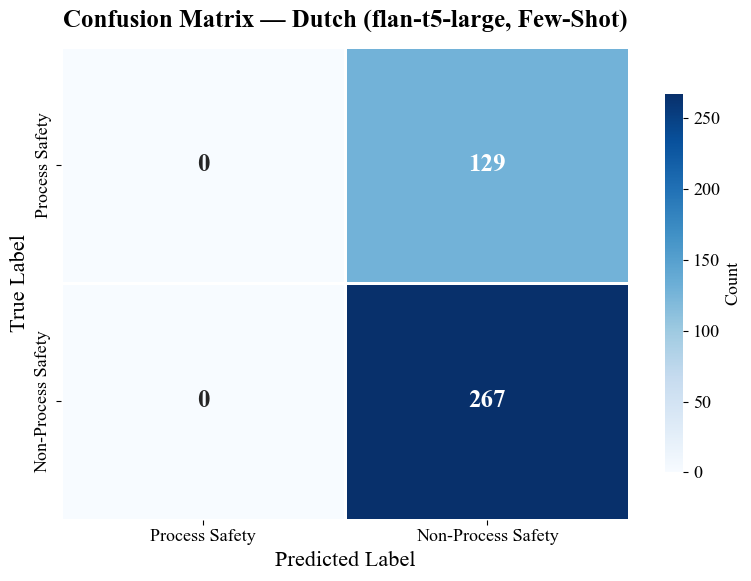

  [OK] Saved: confusion_matrix_dutch_normalised.png + .pdf


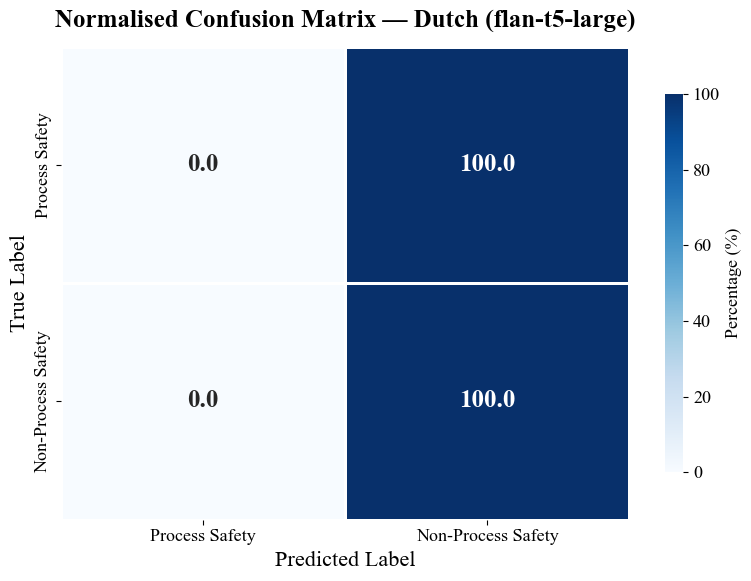

  [OK] Saved: confusion_matrix_english_raw.png + .pdf


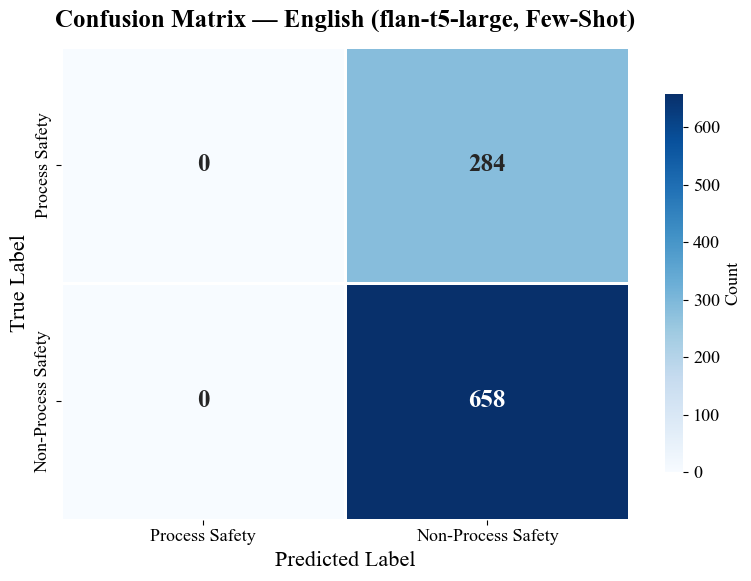

  [OK] Saved: confusion_matrix_english_normalised.png + .pdf


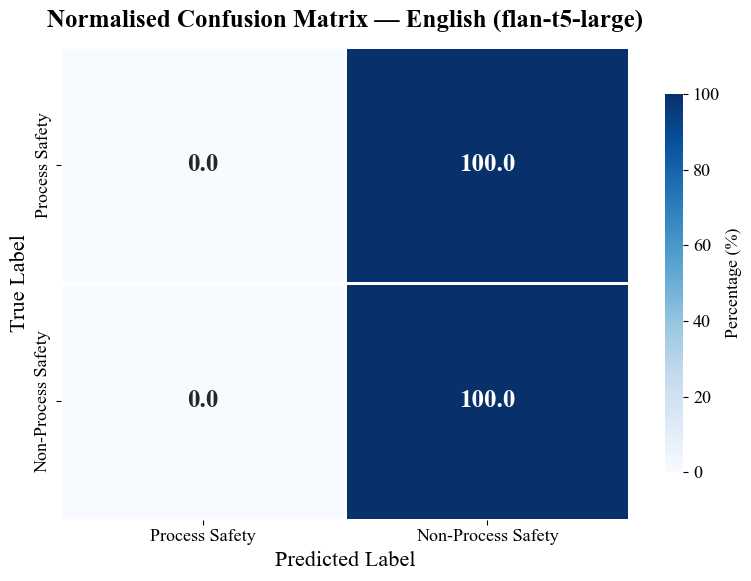

  [OK] Saved: confusion_matrix_german_raw.png + .pdf


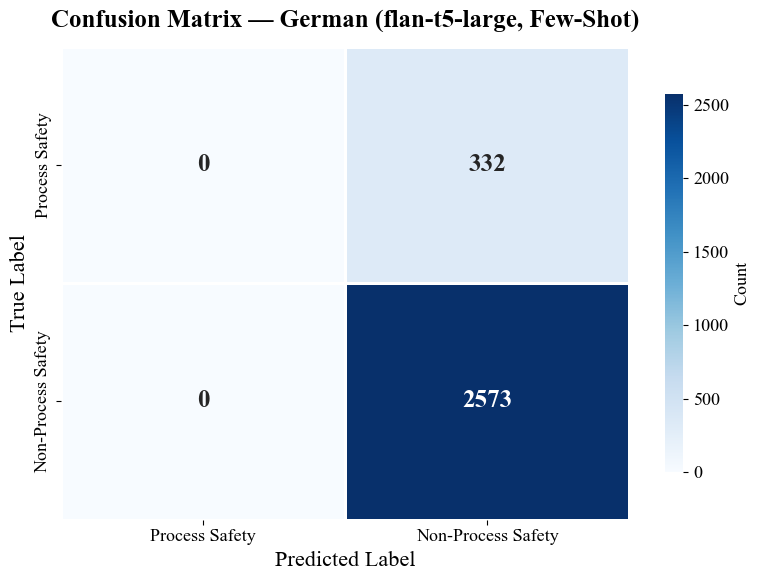

  [OK] Saved: confusion_matrix_german_normalised.png + .pdf


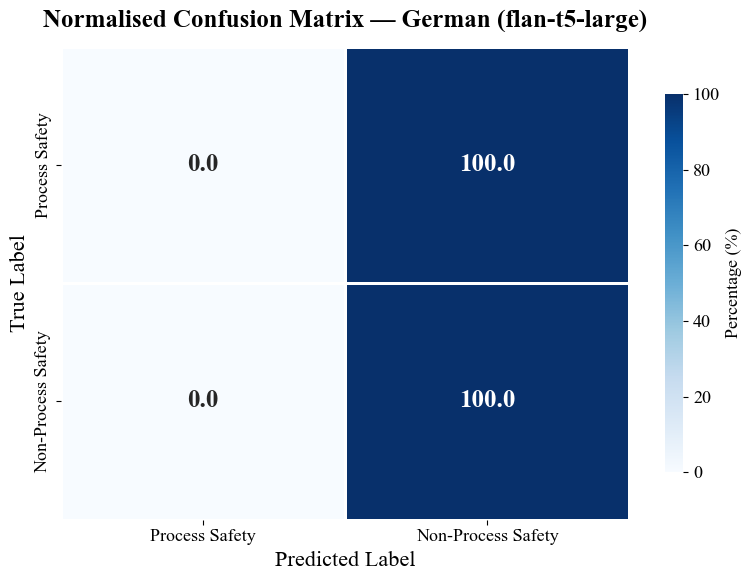

  [OK] Saved: confusion_matrix_swedish_raw.png + .pdf


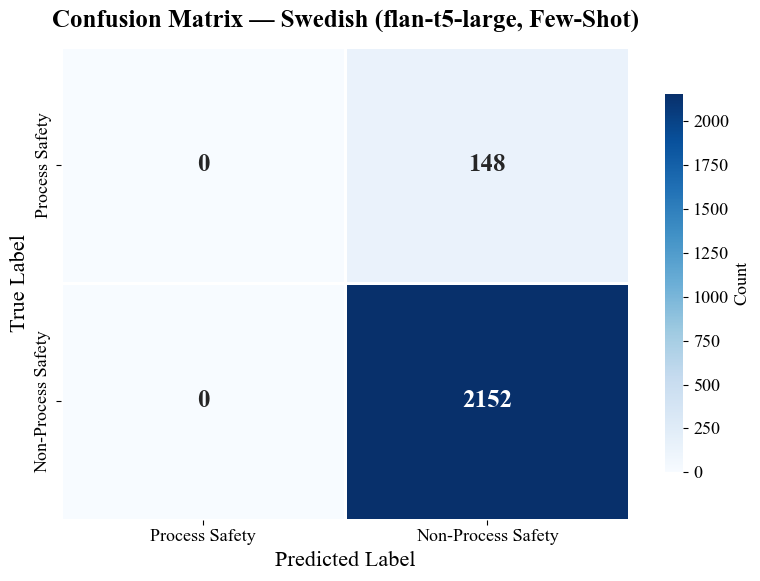

  [OK] Saved: confusion_matrix_swedish_normalised.png + .pdf


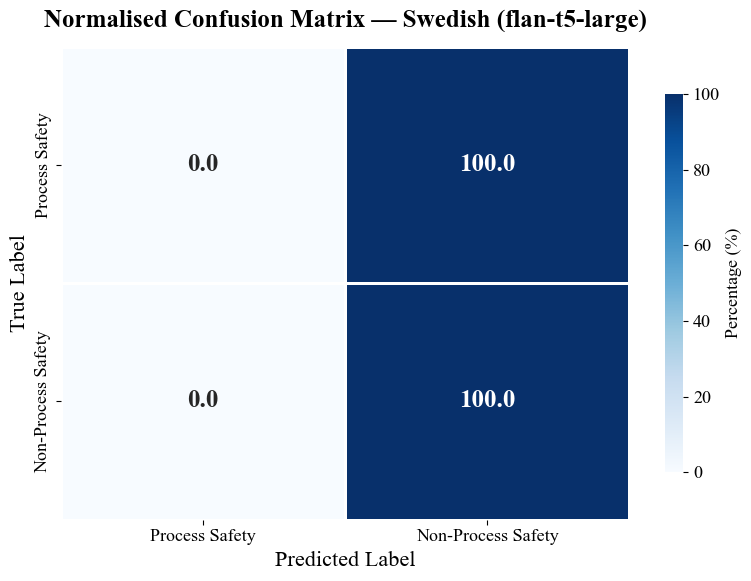

  [OK] Saved: confusion_matrix_overall_raw.png + .pdf


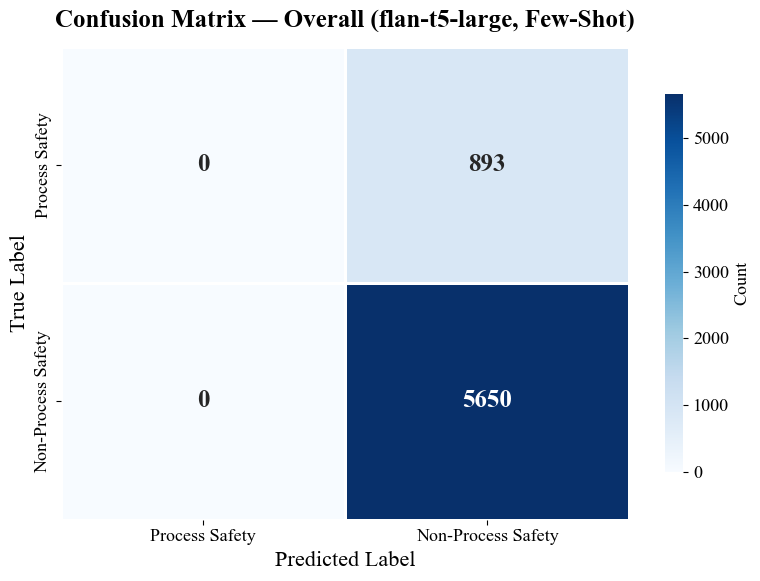

  [OK] Saved: confusion_matrix_overall_normalised.png + .pdf


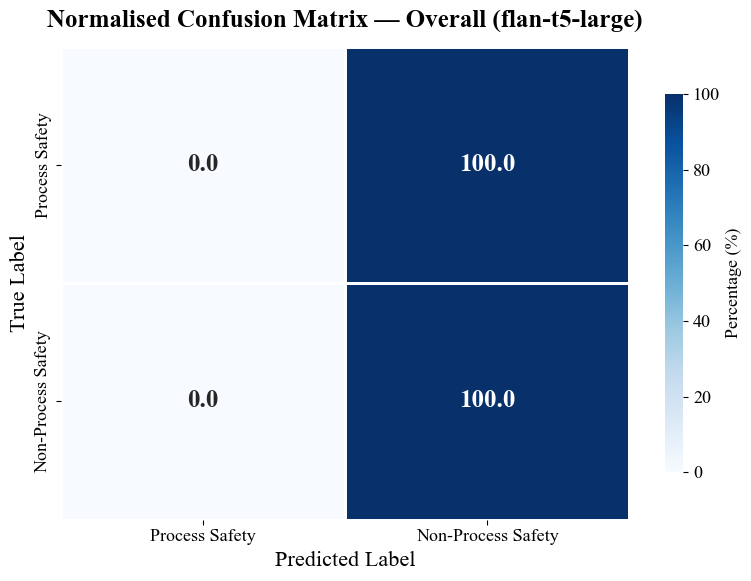

  [OK] Saved: roc_curve_dutch.png + .pdf


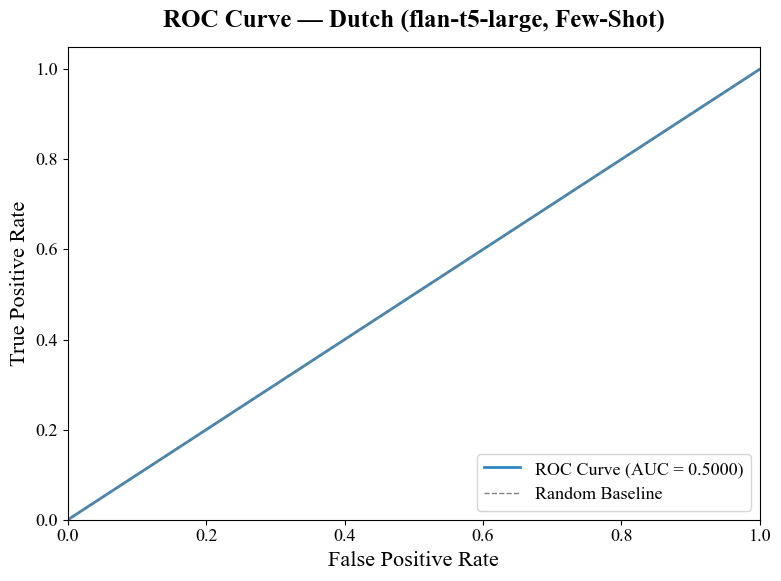

  [OK] Saved: roc_curve_english.png + .pdf


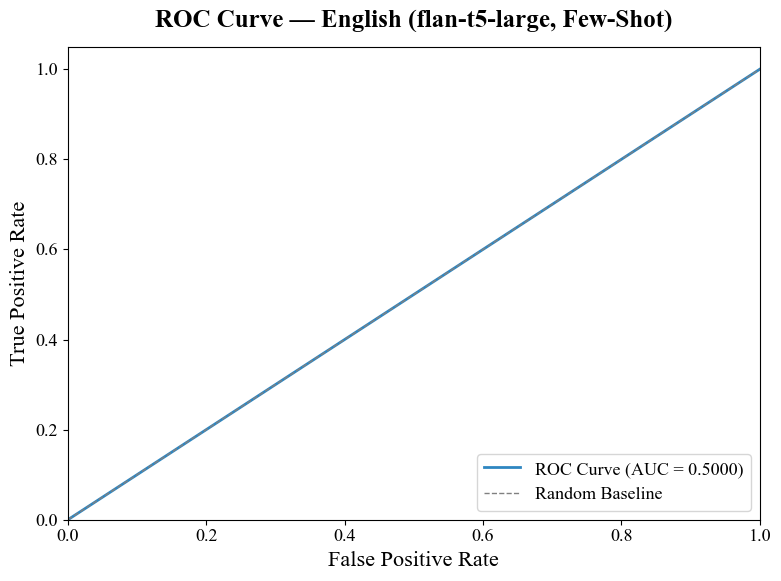

  [OK] Saved: roc_curve_german.png + .pdf


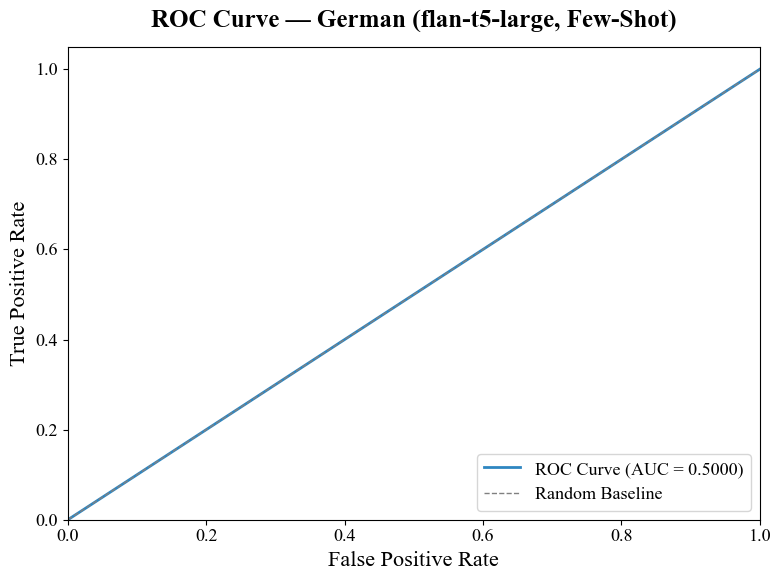

  [OK] Saved: roc_curve_swedish.png + .pdf


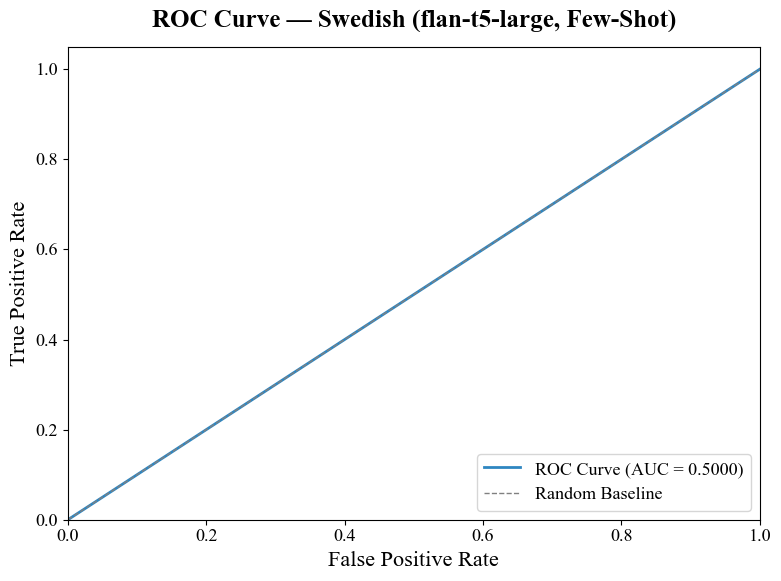

  [OK] Saved: roc_curve_overall.png + .pdf


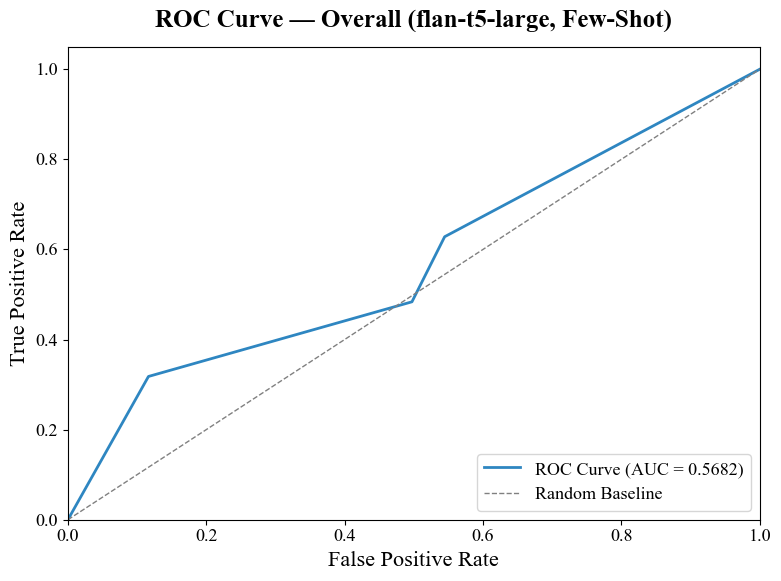

  [OK] Saved: pr_curve_dutch.png + .pdf


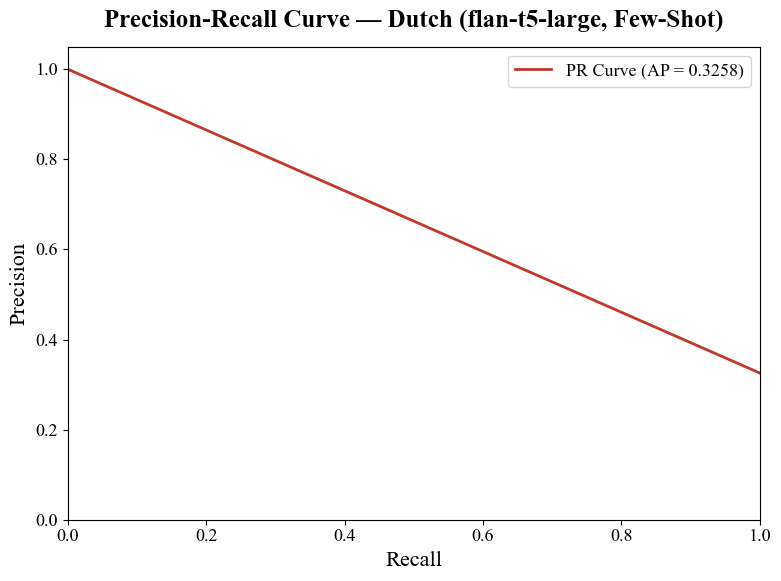

  [OK] Saved: pr_curve_english.png + .pdf


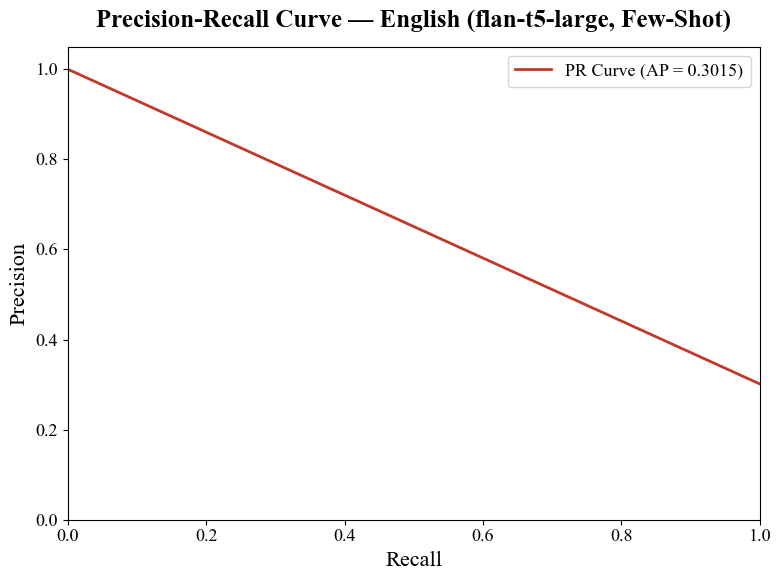

  [OK] Saved: pr_curve_german.png + .pdf


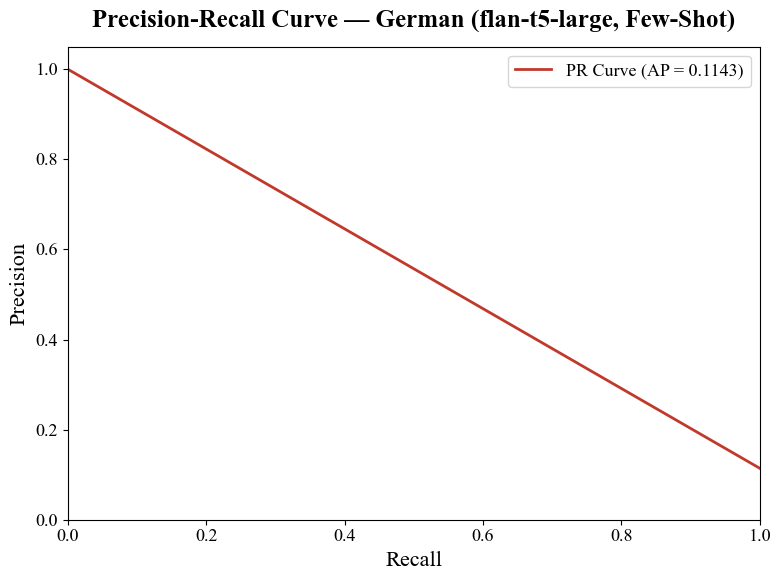

  [OK] Saved: pr_curve_swedish.png + .pdf


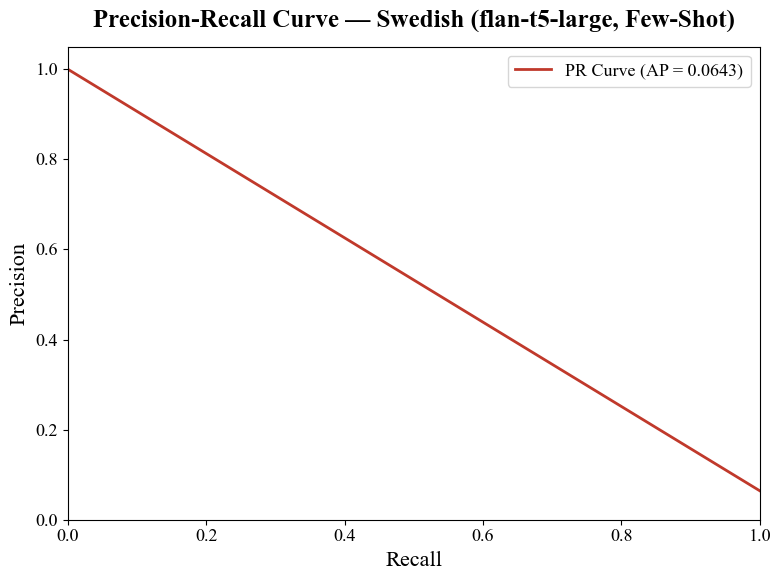

  [OK] Saved: pr_curve_overall.png + .pdf


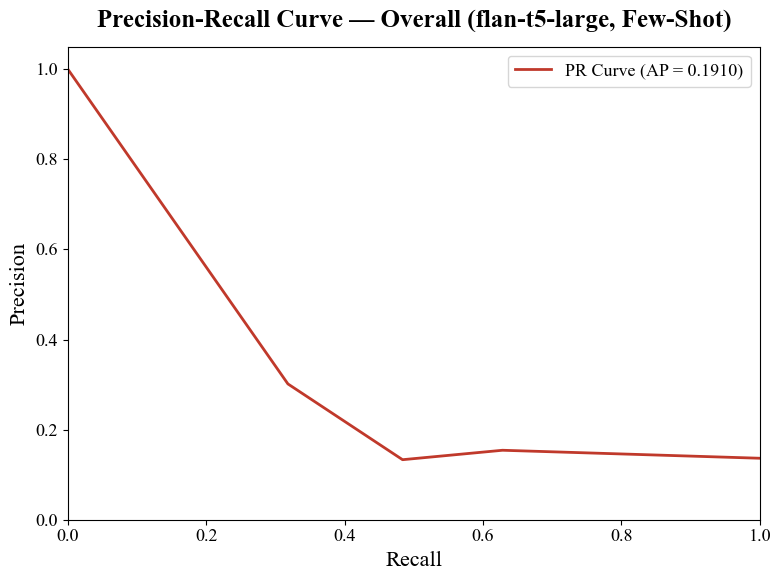

  [OK] Saved: metrics_bar_dutch.png + .pdf


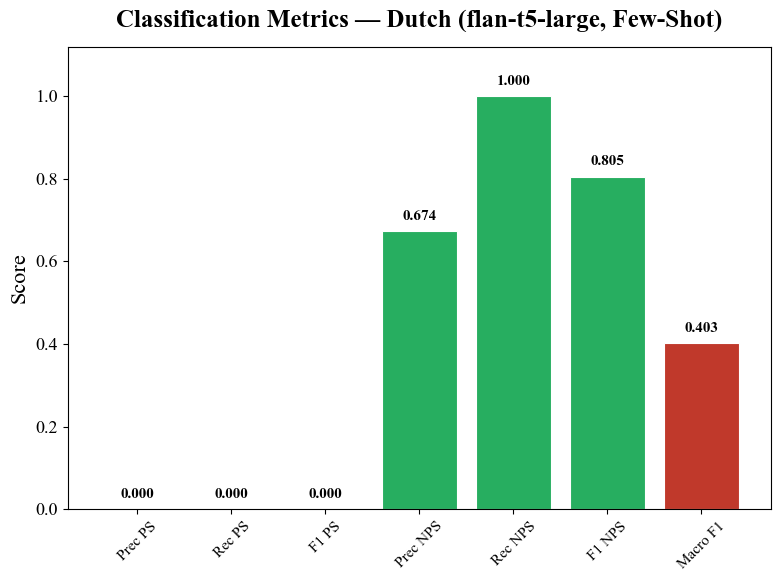

  [OK] Saved: metrics_bar_english.png + .pdf


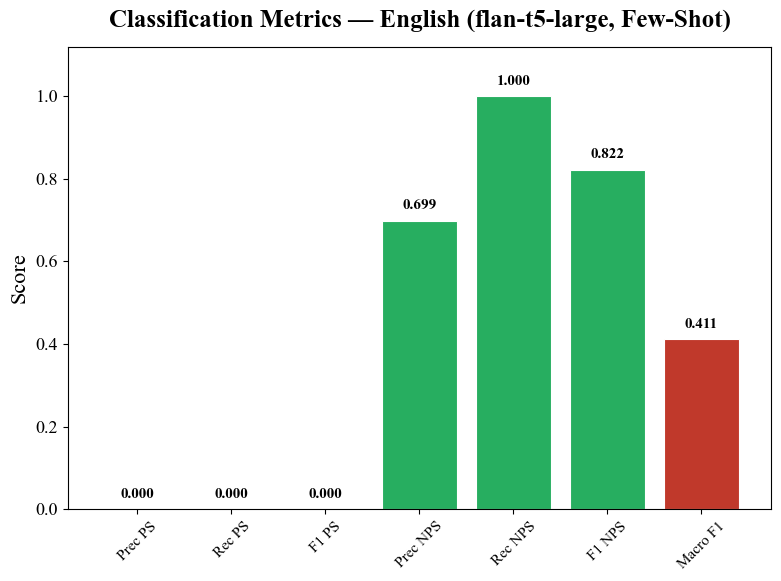

  [OK] Saved: metrics_bar_german.png + .pdf


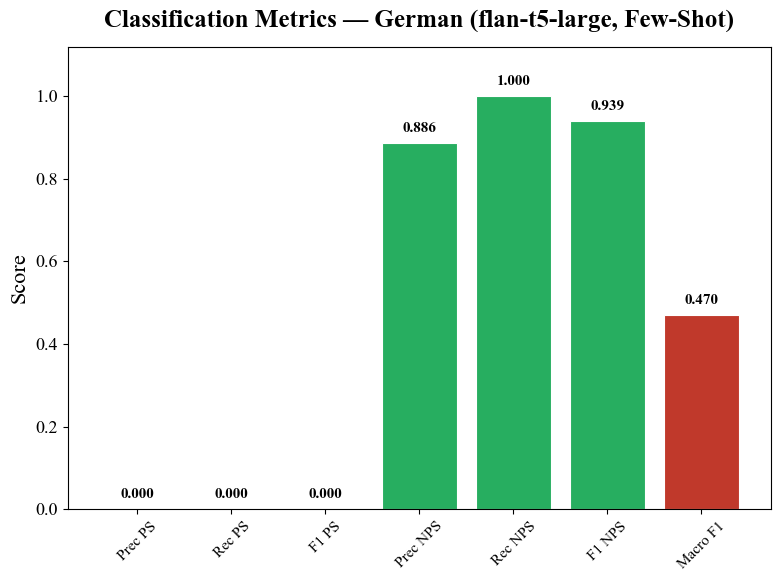

  [OK] Saved: metrics_bar_swedish.png + .pdf


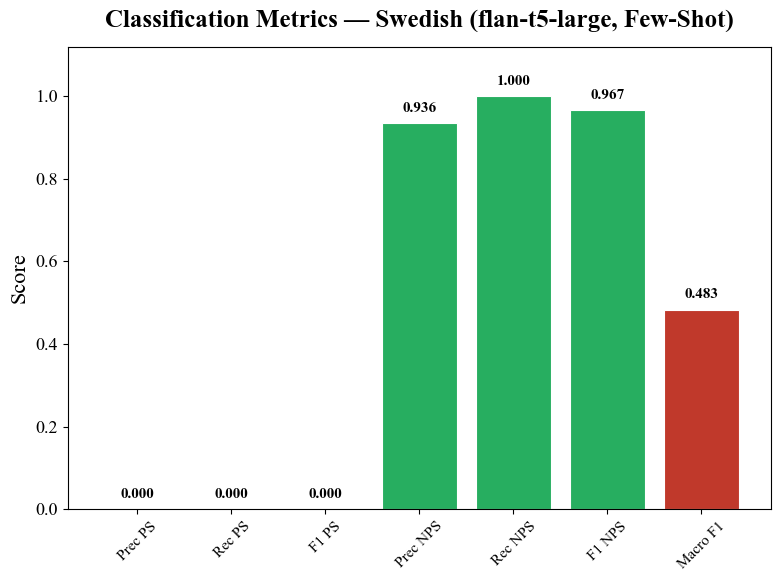

  [OK] Saved: metrics_bar_overall.png + .pdf


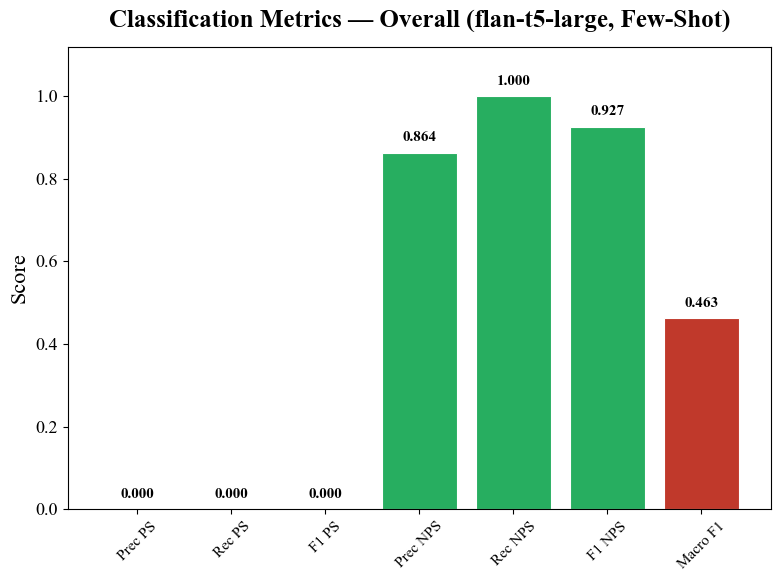


[OK] All per-language and overall academic visualisations complete.


In [17]:
# =============================================================================
# VISUALISATIONS — PER-LANGUAGE AND OVERALL
# =============================================================================
# standard: Times New Roman serif, 8×6, 300 dpi, PNG + PDF dual export

FIGURES_DIR = PATHS["figures"]

def _apply_academic_rcparams():
    """Apply standard matplotlib rcParams (Times New Roman serif)."""
    matplotlib.rcParams.update({
        'font.family': 'serif',
        'font.serif':  ['Times New Roman', 'DejaVu Serif'],
        'font.size':   13,
    })


def _restore_rcparams():
    """Restore default matplotlib rcParams after academic plotting."""
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)


def _save_academic_figure(fig, base_name):
    """Save figure as PNG (300 dpi) + PDF and close."""
    png_path = FIGURES_DIR / f'{base_name}.png'
    pdf_path = FIGURES_DIR / f'{base_name}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f"  [OK] Saved: {base_name}.png + .pdf")
    plt.show()
    plt.close(fig)


# ── Load predictions for the best model ──────────────────────────────────────
best_model_short = summary_df.iloc[0]["Model"]
best_model_full = [m for m in MODELS_TO_COMPARE if m.split("/")[-1] == best_model_short][0]
best_pred_path = Path(all_model_prediction_files[best_model_full])
pred_df = pd.read_csv(best_pred_path)

# Binary-encode labels for ROC / PR computation
pred_df["y_true"] = (pred_df["gold_label"] == "Process Safety").astype(int)
pred_df["y_pred"] = (pred_df["pred_label"] == "Process Safety").astype(int)

# PS probability: confidence if predicted PS, else 1 - confidence
pred_df["ps_prob"] = np.where(
    pred_df["pred_label"] == "Process Safety",
    pred_df["pred_confidence"],
    1.0 - pred_df["pred_confidence"]
)

# Build per-language + overall evaluation groups
eval_groups = {}
for lang in sorted(pred_df["LANGUAGE"].unique()):
    eval_groups[lang] = pred_df[pred_df["LANGUAGE"] == lang].copy()
eval_groups["Overall"] = pred_df.copy()

print(f"[INFO] Model: {best_model_short}")
print(f"[INFO] Languages: {sorted(pred_df['LANGUAGE'].unique().tolist())} + Overall")

# ── 1. Confusion matrices (raw + normalised) ────────────────────────────────
for group_name, group_df in eval_groups.items():
    y_true = group_df["y_true"].values
    y_pred = group_df["y_pred"].values
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # [[TP, FN], [FP, TN]]

    # Raw counts
    _apply_academic_rcparams()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Process Safety', 'Non-Process Safety'],
        yticklabels=['Process Safety', 'Non-Process Safety'],
        cbar_kws={'label': 'Count', 'shrink': 0.8},
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 18, 'fontweight': 'bold'},
        ax=ax,
    )
    ax.set_title(
        f'Confusion Matrix — {group_name} ({best_model_short}, Few-Shot)',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.set_ylabel('True Label', fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=16)
    ax.tick_params(labelsize=13)
    fig.tight_layout()
    _save_academic_figure(fig, f'confusion_matrix_{group_name.lower()}_raw')
    _restore_rcparams()

    # Normalised
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    _apply_academic_rcparams()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=['Process Safety', 'Non-Process Safety'],
        yticklabels=['Process Safety', 'Non-Process Safety'],
        cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 18, 'fontweight': 'bold'},
        ax=ax,
    )
    ax.set_title(
        f'Normalised Confusion Matrix — {group_name} ({best_model_short})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.set_ylabel('True Label', fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=16)
    ax.tick_params(labelsize=13)
    fig.tight_layout()
    _save_academic_figure(fig, f'confusion_matrix_{group_name.lower()}_normalised')
    _restore_rcparams()

# ── 2. ROC curves ────────────────────────────────────────────────────────────
for group_name, group_df in eval_groups.items():
    y_true = group_df["y_true"].values
    ps_probs = group_df["ps_prob"].values

    # Skip ROC if only one class present
    if len(np.unique(y_true)) < 2:
        print(f"  [SKIP] ROC for {group_name}: single class in ground truth")
        continue

    _apply_academic_rcparams()
    fpr, tpr, _ = roc_curve(y_true, ps_probs)
    auc_val = roc_auc_score(y_true, ps_probs)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='#2e86c1', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Baseline')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)
    ax.set_title(
        f'ROC Curve — {group_name} ({best_model_short}, Few-Shot)',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.legend(loc='lower right', fontsize=13)
    ax.tick_params(labelsize=13)
    fig.tight_layout()
    _save_academic_figure(fig, f'roc_curve_{group_name.lower()}')
    _restore_rcparams()

# ── 3. Precision-Recall curves ───────────────────────────────────────────────
for group_name, group_df in eval_groups.items():
    y_true = group_df["y_true"].values
    ps_probs = group_df["ps_prob"].values

    if len(np.unique(y_true)) < 2:
        print(f"  [SKIP] PR curve for {group_name}: single class in ground truth")
        continue

    _apply_academic_rcparams()
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, ps_probs)
    ap = average_precision_score(y_true, ps_probs)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_vals, precision_vals, color='#c0392b', lw=2,
            label=f'PR Curve (AP = {ap:.4f})')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=16)
    ax.set_ylabel('Precision', fontsize=16)
    ax.set_title(
        f'Precision-Recall Curve — {group_name} ({best_model_short}, Few-Shot)',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.legend(loc='upper right', fontsize=13)
    ax.tick_params(labelsize=13)
    fig.tight_layout()
    _save_academic_figure(fig, f'pr_curve_{group_name.lower()}')
    _restore_rcparams()

# ── 4. Per-language + overall metrics bar charts ─────────────────────────────
for group_name, group_df in eval_groups.items():
    y_true = group_df["y_true"].values
    y_pred = group_df["y_pred"].values

    prec_ps  = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_ps   = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_ps    = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    prec_nps = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_nps  = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_nps   = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    metrics_dict = {
        'Prec PS':  prec_ps,
        'Rec PS':   rec_ps,
        'F1 PS':    f1_ps,
        'Prec NPS': prec_nps,
        'Rec NPS':  rec_nps,
        'F1 NPS':   f1_nps,
        'Macro F1': macro_f1,
    }

    labels = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    n_ps = sum(1 for l in labels if 'PS' in l and 'NPS' not in l and 'Macro' not in l)
    n_nps = sum(1 for l in labels if 'NPS' in l)
    colors = (['#2e86c1'] * n_ps) + (['#27ae60'] * n_nps) + (['#c0392b'] * (len(labels) - n_ps - n_nps))

    _apply_academic_rcparams()
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score', fontsize=16)
    ax.set_title(
        f'Classification Metrics — {group_name} ({best_model_short}, Few-Shot)',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=13)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    fig.tight_layout()
    _save_academic_figure(fig, f'metrics_bar_{group_name.lower()}')
    _restore_rcparams()

print('\n[OK] All per-language and overall academic visualisations complete.')

## 18. Test Error Analysis

Loads predictions from the best-performing model and extracts misclassified test records. Saved to `artifacts/test_errors_{model}.csv` for qualitative inspection of failure modes.

In [18]:
# =============================================================================
# TEST ERROR ANALYSIS
# =============================================================================
# Use the best-performing model for the main error-analysis file
best_model_name = summary_df.iloc[0]["Model"]
best_model_full_name = [m for m in MODELS_TO_COMPARE if m.split("/")[-1] == best_model_name][0]

best_pred_path = Path(all_model_prediction_files[best_model_full_name])
best_pred_df = pd.read_csv(best_pred_path)

test_errors = best_pred_df[best_pred_df["gold_label"] != best_pred_df["pred_label"]].copy()
test_errors.to_csv(PATHS["artifacts"] / f"test_errors_{best_model_name}.csv", index=False)

test_errors.head(30)


,text_id,LANGUAGE,TITLE,CASE_DESCRIPTION,gold_label,pred_label,pred_confidence,score_margin,top2_labels,top2_probs
5,26,English,PEM120 - Aux Steam Line to D/A Leak,U2 Aux steam line to D/A leak. Leak is located...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
7,35,English,ACC Fans Unguarded,Whilst carrying out a site walk i have noticed...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
8,40,English,SWRO 'B' LP discharge pipework blown out.,When attempting to prove that a three way valv...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
11,55,English,Sodium Hypochlorite leak.,Sodium Hypochlorite leak found on discharge pi...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
16,82,English,SWRO skid 2 end cap blew out,SWRO skid 2 end cap blew out. This cap is loca...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
17,86,English,Regeneration Unit Failed to Start Due to Froze...,"While starting up regen unit 30 (RGU 30), cont...",Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
18,90,English,Failed Pressure Transmitter on the Stripping G...,"During active injection nomination, one of the...",Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
19,95,English,WTP Acid Measuring Tank leak,The Water Treatment Plant Acid Measuring Tank ...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
22,111,English,Exposed live cable,Scaffolder reported a smouldering cable that f...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"
31,155,English,Fire in GT 12 air intake filter house,A program of structural work was in progress a...,Process Safety,Non-Process Safety,0.881682,2.008452,"[""Non-Process Safety"", ""Process Safety""]","[0.8816816138908676, 0.11831838610913235]"


## 19. Aggregate Performance Comparison

Produces one separate academic bar chart per key metric (accuracy, macro-F1, PS precision, PS recall) comparing all benchmarked models side by side. The RQ2 target line is overlaid on the macro-F1 chart.

  [OK] Saved: aggregate_accuracy_by_language.png + .pdf


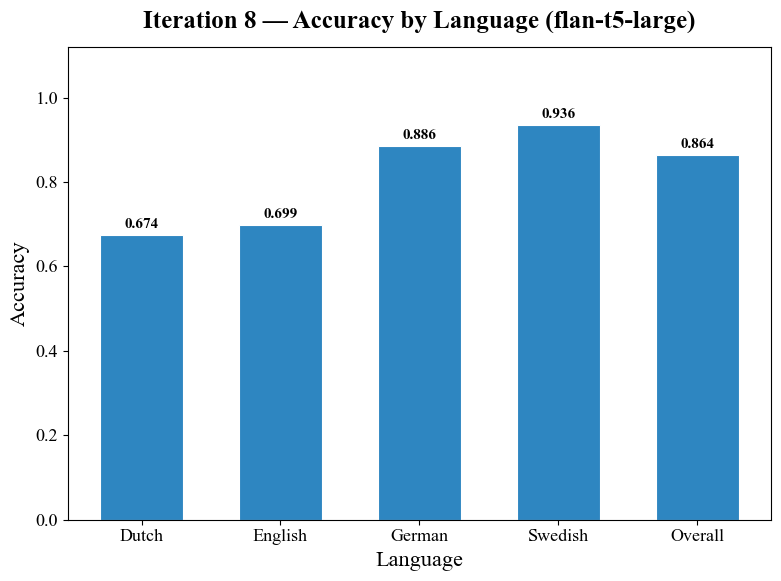

  [OK] Saved: aggregate_macro_f1_by_language.png + .pdf


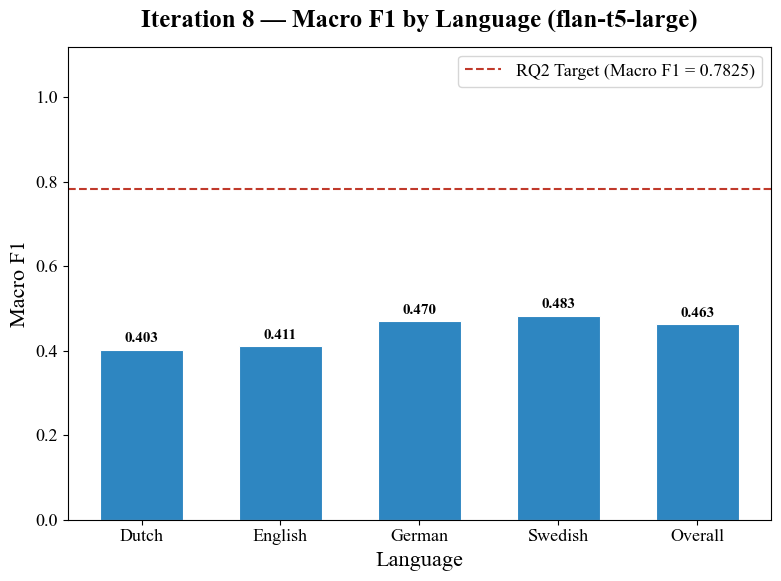

  [OK] Saved: aggregate_ps_recall_by_language.png + .pdf


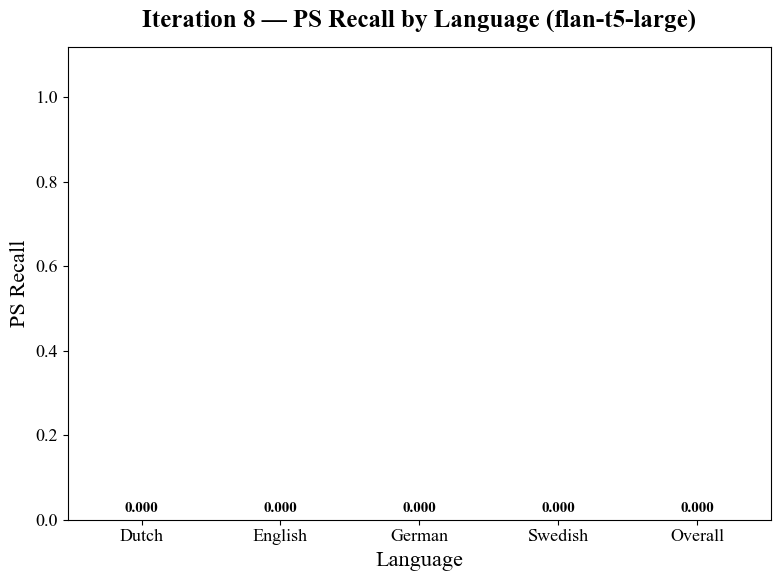

  [OK] Saved: aggregate_ps_precision_by_language.png + .pdf


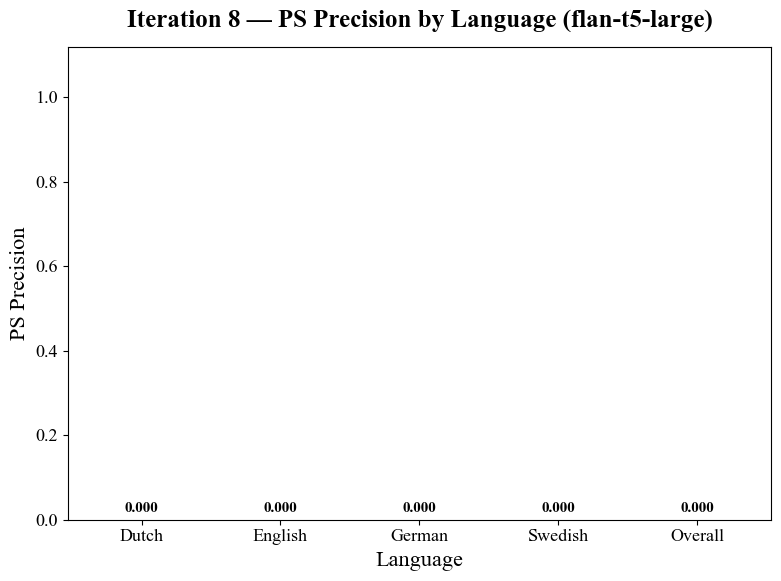


[OK] Aggregate comparison figures complete.


In [19]:
# =============================================================================
# AGGREGATE PERFORMANCE COMPARISON — ALL MODELS
# =============================================================================

# ── Per-language aggregate figures for each key metric ────────────────────────
lang_labels = sorted(pred_df["LANGUAGE"].unique().tolist()) + ["Overall"]

lang_metrics = {}
for lang in lang_labels:
    sub = pred_df if lang == "Overall" else pred_df[pred_df["LANGUAGE"] == lang]
    y_t = sub["y_true"].values
    y_p = sub["y_pred"].values
    lang_metrics[lang] = {
        'Accuracy':     accuracy_score(y_t, y_p),
        'Macro F1':     f1_score(y_t, y_p, average='macro', zero_division=0),
        'PS Recall':    recall_score(y_t, y_p, pos_label=1, zero_division=0),
        'PS Precision': precision_score(y_t, y_p, pos_label=1, zero_division=0),
    }

x = np.arange(len(lang_labels))
for metric_name in ['Accuracy', 'Macro F1', 'PS Recall', 'PS Precision']:
    values = [lang_metrics[l][metric_name] for l in lang_labels]

    _apply_academic_rcparams()
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(x, values, width=0.6, color='#2e86c1', edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    if metric_name == 'Macro F1':
        ax.axhline(y=RQ2_TARGET_MACRO_F1, color='#c0392b', linestyle='--', lw=1.5,
                   label=f'RQ2 Target (Macro F1 = {RQ2_TARGET_MACRO_F1})')
        ax.legend(fontsize=13)

    ax.set_xlabel('Language', fontsize=16)
    ax.set_ylabel(metric_name, fontsize=16)
    ax.set_title(
        f'Iteration 8 — {metric_name} by Language ({best_model_short})',
        fontsize=18, fontweight='bold', pad=14,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(lang_labels, fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.tick_params(labelsize=13)
    fig.tight_layout()

    safe_name = metric_name.replace(' ', '_').lower()
    _save_academic_figure(fig, f'aggregate_{safe_name}_by_language')
    _restore_rcparams()

# ── Model comparison (if multiple models benchmarked) ─────────────────────────
if len(all_model_metrics) > 1:
    model_names = [m.split("/")[-1] for m in all_model_metrics.keys()]
    model_x = np.arange(len(model_names))

    for metric_key, metric_label in [("macro_f1", "Macro F1"), ("accuracy", "Accuracy")]:
        values = [all_model_metrics[m][metric_key] for m in all_model_metrics.keys()]

        _apply_academic_rcparams()
        fig, ax = plt.subplots(figsize=(8, 6))
        bars = ax.bar(model_x, values, width=0.5, color='#2e86c1', edgecolor='white', linewidth=0.8)

        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        if metric_key == "macro_f1":
            ax.axhline(y=RQ2_TARGET_MACRO_F1, color='#c0392b', linestyle='--', lw=1.5,
                       label=f'RQ2 Target ({RQ2_TARGET_MACRO_F1})')
            ax.legend(fontsize=13)

        ax.set_xlabel('Model', fontsize=16)
        ax.set_ylabel(metric_label, fontsize=16)
        ax.set_title(
            f'Iteration 8 — {metric_label} Model Comparison',
            fontsize=18, fontweight='bold', pad=14,
        )
        ax.set_xticks(model_x)
        ax.set_xticklabels(model_names, fontsize=11)
        ax.set_ylim(0, 1.12)
        ax.tick_params(labelsize=13)
        fig.tight_layout()
        _save_academic_figure(fig, f'model_comparison_{metric_key}')
        _restore_rcparams()

print('\n[OK] Aggregate comparison figures complete.')

## 20. Save Final Iteration Summary

Exports `iteration_8_merged_summary.json` containing iteration metadata, per-model benchmark results, gap analysis against the RQ2 target, and links to all output artefacts.

In [20]:
# =============================================================================
# FINAL SUMMARY JSON
# =============================================================================
def _json_safe(v):
    """Recursively convert NumPy scalars and Path objects to JSON-safe types."""
    if isinstance(v, dict):
        return {k: _json_safe(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)):
        return [_json_safe(x) for x in v]
    if isinstance(v, np.generic):
        return v.item()
    if isinstance(v, Path):
        return str(v)
    return v

iteration_summary = {
    "iteration": 8,
    "research_question": "RQ2 - Merged exploratory + benchmark notebook",
    "task": "Binary Process Safety vs Non-Process Safety classification",
    "models": MODELS_TO_COMPARE,
    "languages": sorted(df["LANGUAGE"].unique().tolist()),
    "data_rows": int(len(df)),
    "unique_texts": int(df["text_id"].nunique()),
    "rq2_target_macro_f1": float(RQ2_TARGET_MACRO_F1),
    "exploratory_outputs": {
        "validation_debug_predictions": str(PATHS["artifacts"] / "validation_debug_predictions.csv"),
        "validation_debug_errors": str(PATHS["artifacts"] / "validation_debug_errors.csv"),
        "few_shot_exemplars": str(PATHS["artifacts"] / "few_shot_exemplars.json"),
    },
    "benchmark_outputs": {
        "summary_csv": str(PATHS["metrics"] / "model_comparison_summary.csv"),
        "metrics_json": str(PATHS["metrics"] / "all_model_metrics.json"),
    },
    "results": {}
}

for model_name, metrics in all_model_metrics.items():
    short_name = model_name.split("/")[-1]
    macro_f1 = float(metrics["macro_f1"])
    iteration_summary["results"][short_name] = {
        "accuracy": float(metrics["accuracy"]),
        "macro_precision": float(metrics["macro_precision"]),
        "macro_recall": float(metrics["macro_recall"]),
        "macro_f1": macro_f1,
        "target_met": bool(macro_f1 >= float(RQ2_TARGET_MACRO_F1)),
        "gap_to_target": float(macro_f1 - float(RQ2_TARGET_MACRO_F1)),
        "prediction_file": str(all_model_prediction_files[model_name]),
    }

with open(PATHS["results"] / "iteration_8_merged_summary.json", "w", encoding="utf-8") as f:
    json.dump(_json_safe(iteration_summary), f, indent=2)

iteration_summary

{'iteration': 8,
 'research_question': 'RQ2 - Merged exploratory + benchmark notebook',
 'task': 'Binary Process Safety vs Non-Process Safety classification',
 'models': ['google/flan-t5-large'],
 'languages': ['Dutch', 'English', 'German', 'Swedish'],
 'data_rows': 33878,
 'unique_texts': 32717,
 'rq2_target_macro_f1': 0.7825,
 'exploratory_outputs': {'validation_debug_predictions': '/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/artifacts/validation_debug_predictions.csv',
  'validation_debug_errors': '/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/artifacts/validation_debug_errors.csv',
  'few_shot_exemplars': '/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/artifacts/few_shot_exemplars.json'},
 'benchmark_outputs': {'summary_csv': '/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8/metrics/model_comparison_summary.csv',
  'metrics_json': '/Users/shariarimro

In [21]:
print("Iteration 8 merged notebook complete.")
print("Results directory:", PATHS["results"])


Iteration 8 merged notebook complete.
Results directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_8
